In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_excel('EastWestAirlines.xlsx',sheet_name='data')

In [3]:
df.shape

(3999, 12)

In [4]:
df.head(4)

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


###### All the data in the given dataset is of numerical type

In [6]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [7]:
## Checking for missing values
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [8]:
#checking for duplicates
df.duplicated().sum()

np.int64(0)

##### Hence there are no missing and duplicate values present in the given dataset

In [51]:
#### IN the provided dataset, we can drop the ID column as the index value is already present
df_new=df.copy()
df_new=df_new.drop(['ID#'],axis=1)
df_new.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster
0,28143,0,1,1,1,174,1,0,0,7000,0,3
1,19244,0,1,1,1,215,2,0,0,6968,0,3
2,41354,0,1,1,1,4123,4,0,0,7034,0,3
3,14776,0,1,1,1,500,1,0,0,6952,0,3
4,97752,0,4,1,1,43300,26,2077,4,6935,1,2


In [52]:
 ## Finding the numerical columns in the dataset
num_col=df_new.select_dtypes(include='int64').columns
num_col

Index(['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')

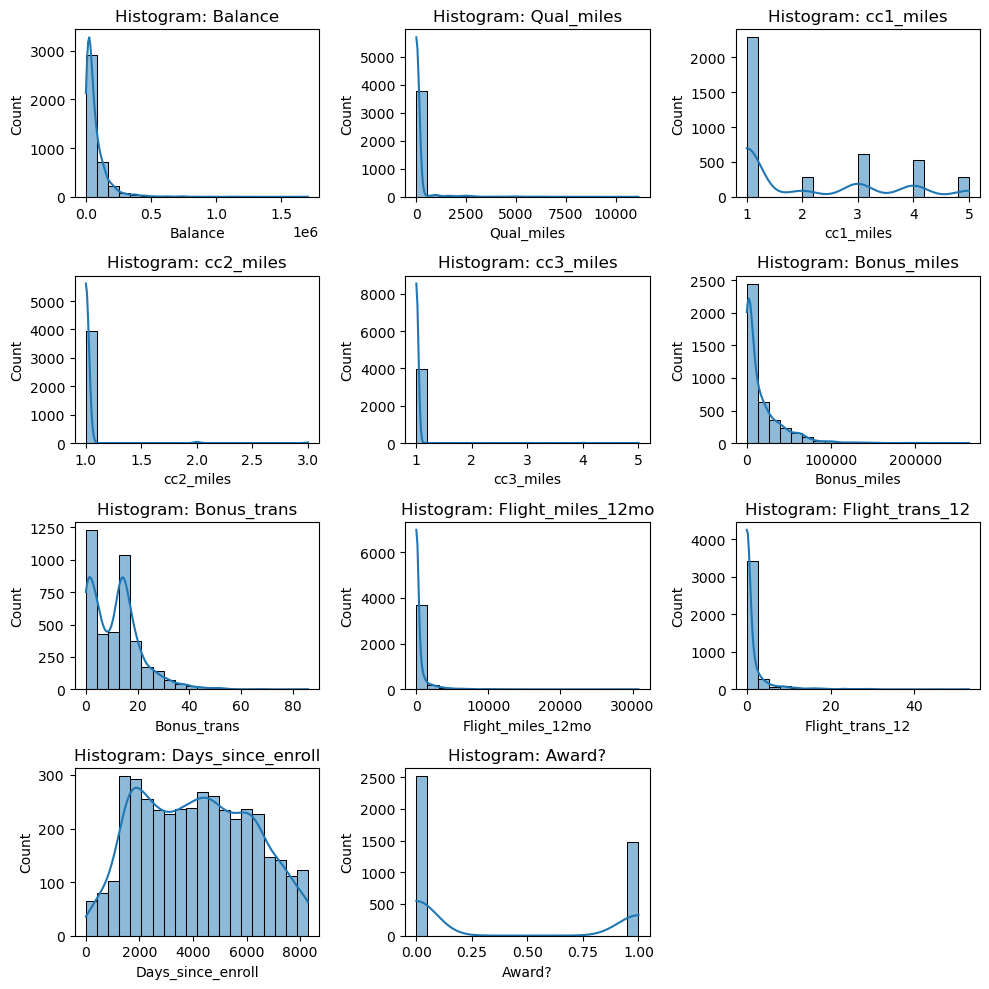

In [53]:
#Plot Histplot Of Each Numerical Columns TO identify Features Distributions
plt.figure(figsize=(10,10))
for i, col in enumerate(num_col, 1):
    plt.subplot(4,3, i)
    sns.histplot(df_new[col], kde=True, bins=20) 
    plt.title(f"Histogram: {col}")
plt.tight_layout()
plt.show()

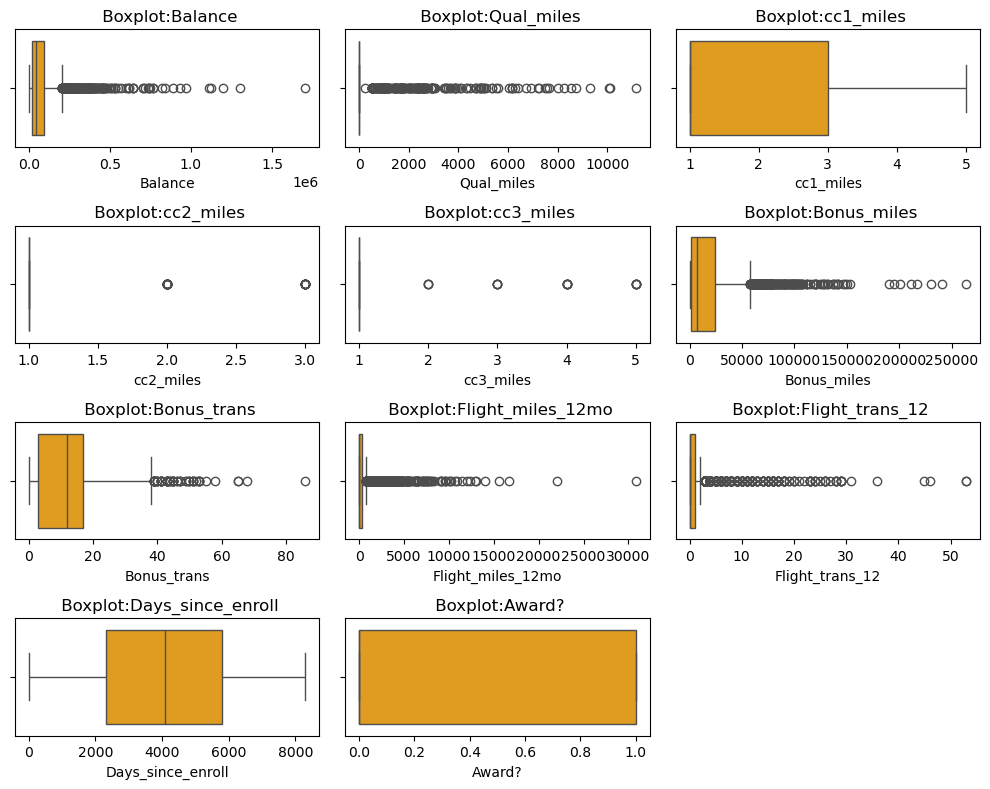

In [54]:
### PLotting boxplot to check for outliers
plt.figure(figsize=(10,8))
for i,col in enumerate(num_col,1):
    plt.subplot(4,3,i)
    sns.boxplot(x=df_new[col],color='orange')
    plt.title(f" Boxplot:{col}")
plt.tight_layout()
plt.show()
    

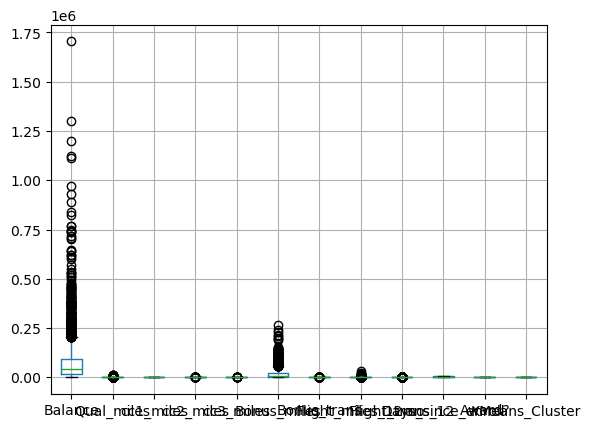

In [55]:
df_new.boxplot()
plt.show()

<Axes: >

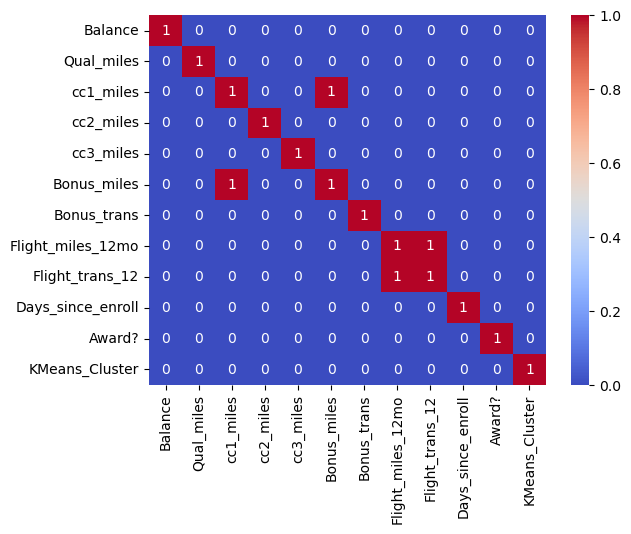

In [56]:
### Plotting heatmap so as to find the correlation between the features
sns.heatmap(df_new.corr(numeric_only = True)>0.7,annot=True,cmap='coolwarm')

#### Implementing Clustering Algorithms:

Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.

Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.

Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.

In [57]:
#### Firstly applying scaling technique so as to data in a particular range value
std_sca=StandardScaler()
scaled_data=std_sca.fit_transform(df_new)
scaled_data=pd.DataFrame(scaled_data,columns=df_new.columns)
scaled_data.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster
0,-0.451141,-0.186299,-0.769578,-0.098242,-0.062767,-0.702786,-1.104065,-0.328603,-0.362168,1.395454,-0.766919,0.947940
1,-0.539457,-0.186299,-0.769578,-0.098242,-0.062767,-0.701088,-0.999926,-0.328603,-0.362168,1.379957,-0.766919,0.947940
2,-0.320031,-0.186299,-0.769578,-0.098242,-0.062767,-0.539253,-0.791649,-0.328603,-0.362168,1.411920,-0.766919,0.947940
3,-0.583799,-0.186299,-0.769578,-0.098242,-0.062767,-0.689286,-1.104065,-0.328603,-0.362168,1.372208,-0.766919,0.947940
4,0.239678,-0.186299,1.409471,-0.098242,-0.062767,1.083121,1.499394,1.154932,0.692490,1.363975,1.303918,0.087955


In [58]:
### Now applying clustering technique to the scaled dataset
### Also using scikit learn for importin linkage,dendrogram,cluster

In [59]:
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [60]:
### Applying KMeans Clustering
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

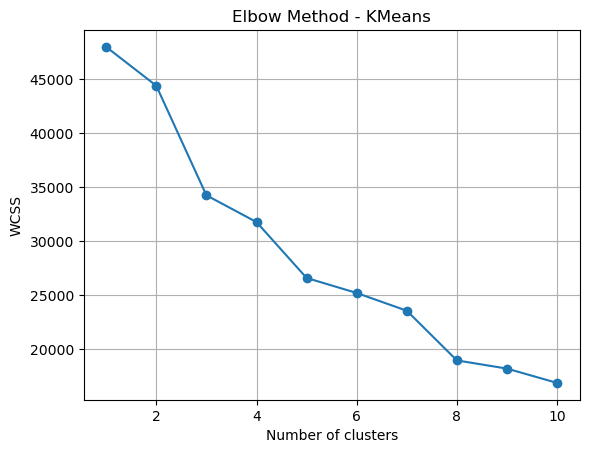

In [61]:
### Plotiing graph for the same so as to get the visual representation
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method - KMeans')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()

In [62]:
### Predicting the values using KMeans clustering and plotting the same 
kmeans = KMeans(n_clusters=4, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(scaled_data)

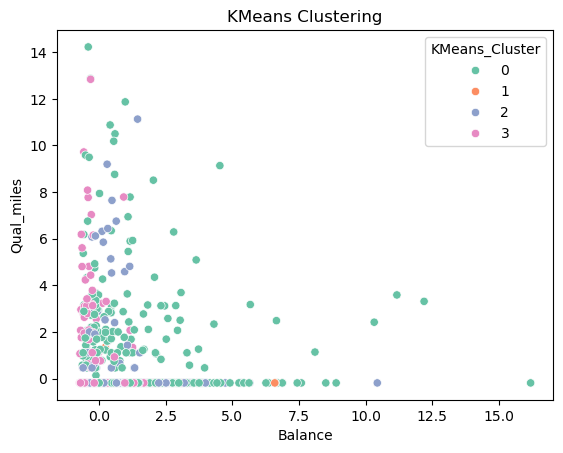

In [63]:
sns.scatterplot(x=scaled_data.iloc[:,0],y=scaled_data.iloc[:,1], hue=df['KMeans_Cluster'], palette='Set2')
plt.title('KMeans Clustering')
plt.show()

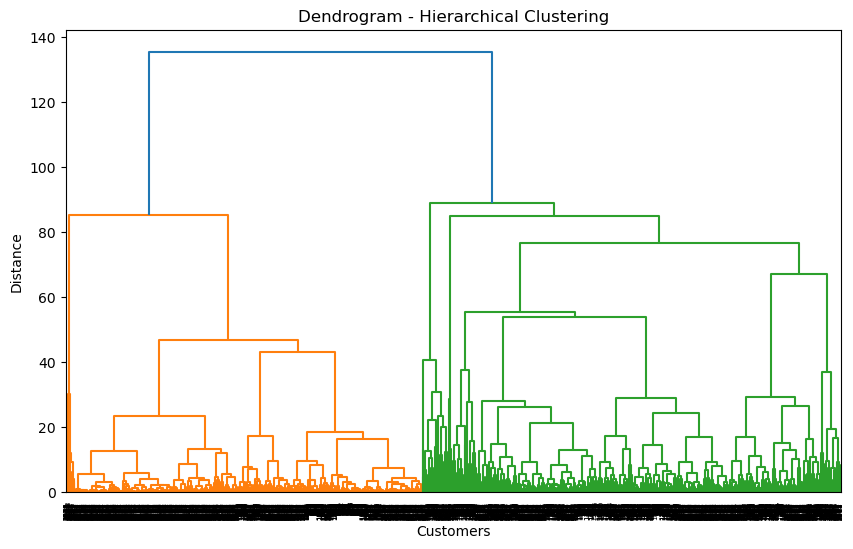

In [64]:
### Plotting the dendrogram hierarchial clustering
linkage_matrix = linkage(scaled_data, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix)
plt.title('Dendrogram - Hierarchical Clustering')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.show()

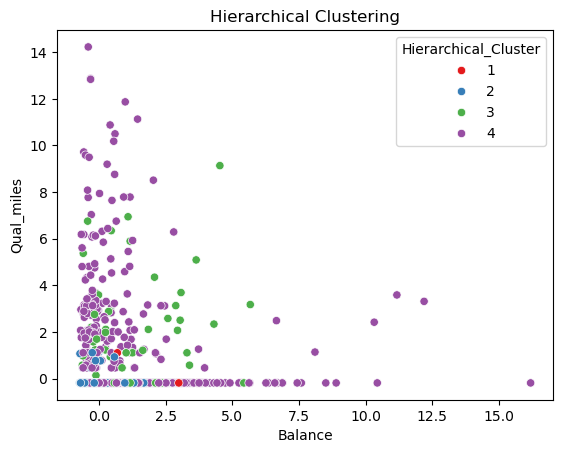

In [67]:
df['Hierarchical_Cluster'] = fcluster(linkage_matrix, t=4, criterion='maxclust')

sns.scatterplot(x=scaled_data.iloc[:, 0], y=scaled_data.iloc[:, 1], hue=df['Hierarchical_Cluster'], palette='Set1')
plt.title('Hierarchical Clustering')
plt.show()

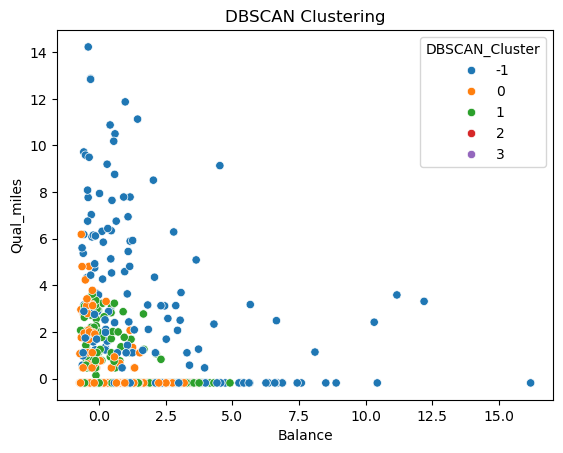

In [70]:
## Now applying DBSCAN Clustering technique
dbscan = DBSCAN(eps=1.8, min_samples=5)  # we can adjust eps as needed
df['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_data)

sns.scatterplot(x=scaled_data.iloc[:, 0], y=scaled_data.iloc[:, 1], hue=df['DBSCAN_Cluster'], palette='tab10')
plt.title('DBSCAN Clustering')
plt.show()

In [71]:
### In DBSCAN clustering technique we have multiple linkage methods. so we plot different methods of linkage 

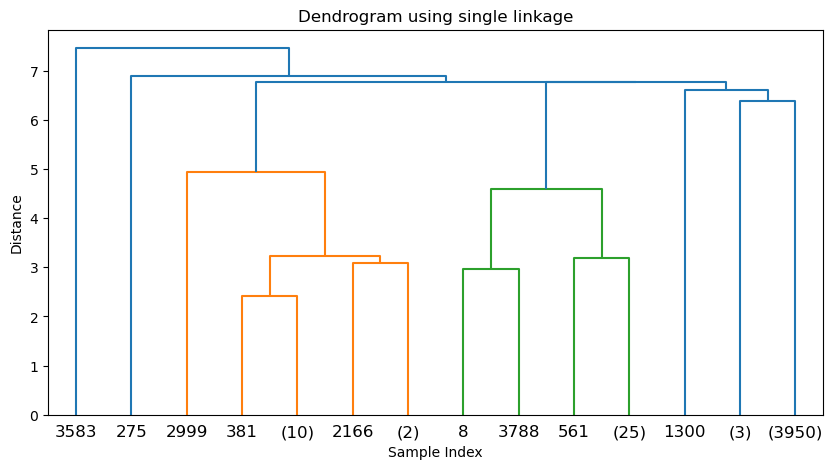

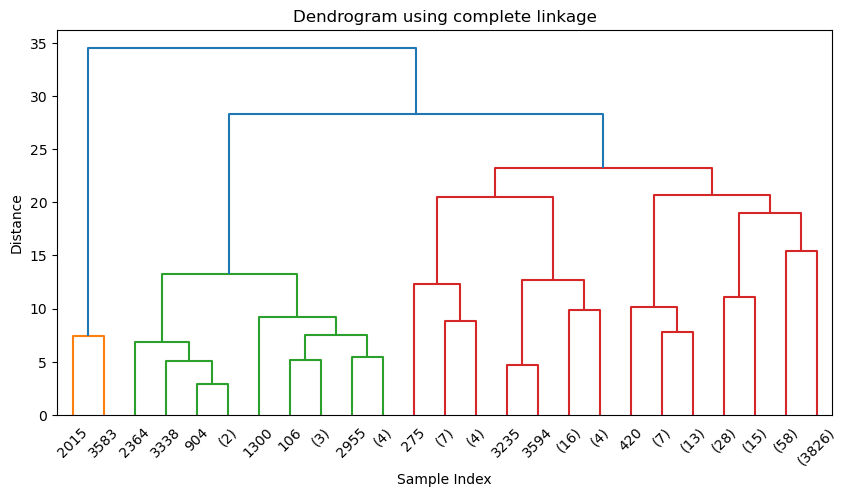

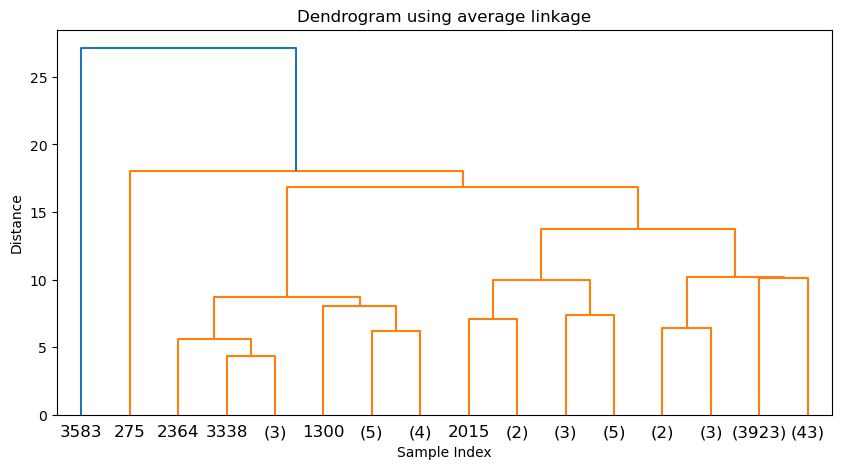

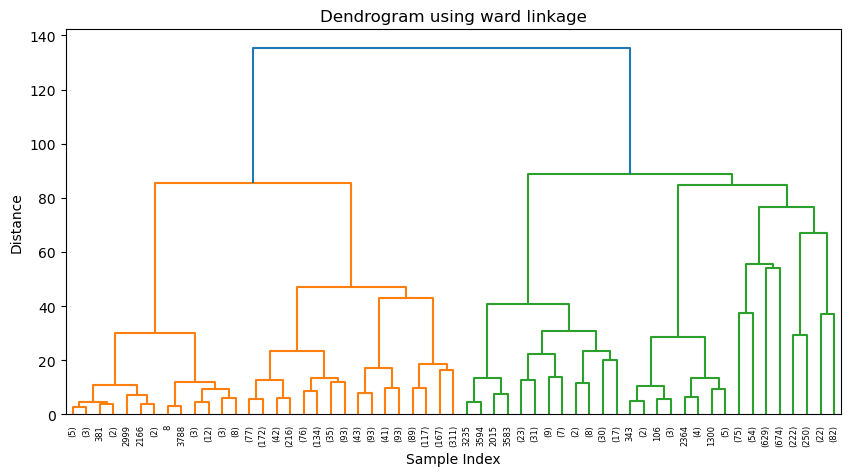

In [72]:
linkage_methods = ['single', 'complete', 'average', 'ward']

for method in linkage_methods:
    plt.figure(figsize=(10, 5))
    Z = linkage(scaled_data, method=method)
    dendrogram(Z, truncate_mode="level", p=5)
    plt.title(f"Dendrogram using {method} linkage")
    plt.xlabel("Sample Index")
    plt.ylabel("Distance")
    plt.show()

In [76]:
# Try multiple combinations to find the silhoutte score
from sklearn.metrics import silhouette_score

eps_values = [1.5, 2, 2.5]
min_samples_values = [3, 5, 10]

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(scaled_data)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        sil_score = -1
        if n_clusters > 1:
            sil_score = silhouette_score(scaled_data, labels)
        print(f"EPS: {eps}, MinPts: {min_samples}, Clusters: {n_clusters}, Silhouette Score: {sil_score:.3f}")

EPS: 1.5, MinPts: 3, Clusters: 9, Silhouette Score: 0.109
EPS: 1.5, MinPts: 5, Clusters: 5, Silhouette Score: 0.132
EPS: 1.5, MinPts: 10, Clusters: 4, Silhouette Score: 0.126
EPS: 2, MinPts: 3, Clusters: 13, Silhouette Score: 0.219
EPS: 2, MinPts: 5, Clusters: 5, Silhouette Score: 0.229
EPS: 2, MinPts: 10, Clusters: 3, Silhouette Score: 0.231
EPS: 2.5, MinPts: 3, Clusters: 5, Silhouette Score: 0.497
EPS: 2.5, MinPts: 5, Clusters: 3, Silhouette Score: 0.513
EPS: 2.5, MinPts: 10, Clusters: 4, Silhouette Score: 0.476


In [77]:
# Summary of clustering
print(df.groupby('KMeans_Cluster').mean(numeric_only=True))
print(df['DBSCAN_Cluster'].value_counts())

                        ID#        Balance  Qual_miles  cc1_miles  cc2_miles  \
KMeans_Cluster                                                                 
0               1645.091061  114435.578947  285.593985   3.058480   1.013367   
1               1664.866667  138061.400000   78.800000   3.466667   1.000000   
2               1880.447339  103968.716874  107.751982   2.686297   1.007928   
3               2312.332458   33338.772584   72.547794   1.129727   1.018382   

                cc3_miles   Bonus_miles  Bonus_trans  Flight_miles_12mo  \
KMeans_Cluster                                                            
0                1.000835  34670.737678    18.360902        1121.033417   
1                4.066667  93927.866667    28.066667         506.666667   
2                1.001133  21680.142695    14.319366         522.340883   
3                1.000525   3418.530987     5.962710          15.262080   

                Flight_trans_12  Days_since_enroll    Award?  \
KMea

#### Cluster Analysis and Interpretation:
##### Analyzing the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. 
#####  Write you insights in few comments.

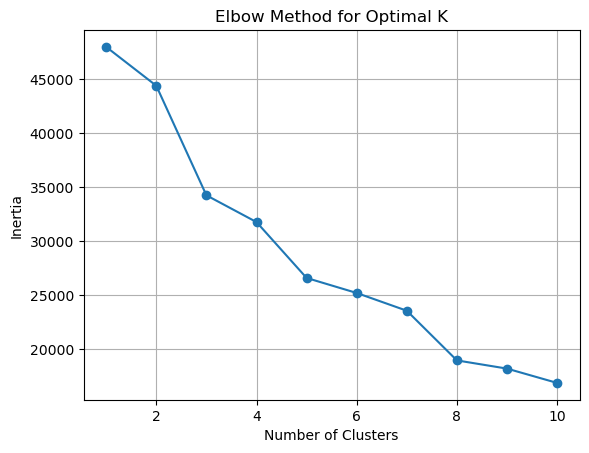

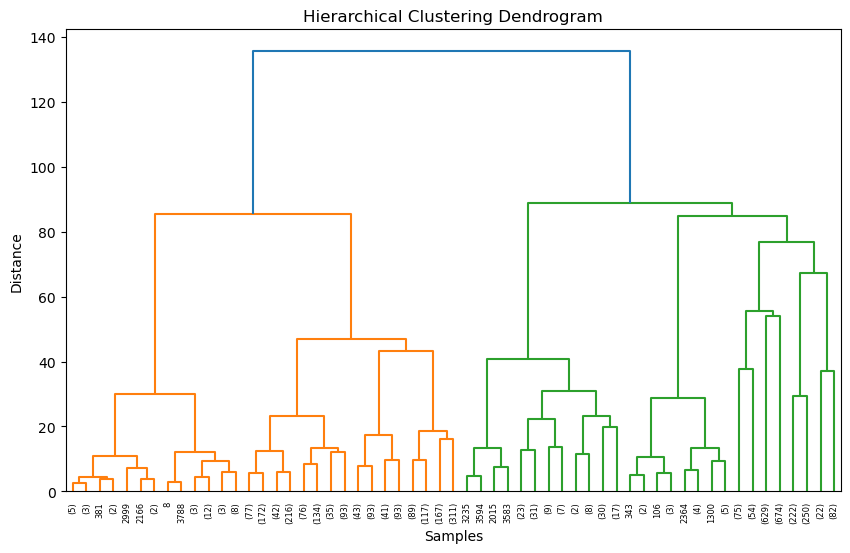

KMeans Cluster Summary:
                         ID#        Balance  Qual_miles  cc1_miles  cc2_miles  \
KMeans_Cluster                                                                 
0               1645.091061  114435.578947  285.593985   3.058480   1.013367   
1               1664.866667  138061.400000   78.800000   3.466667   1.000000   
2               1880.447339  103968.716874  107.751982   2.686297   1.007928   
3               2312.332458   33338.772584   72.547794   1.129727   1.018382   

                cc3_miles   Bonus_miles  Bonus_trans  Flight_miles_12mo  \
KMeans_Cluster                                                            
0                1.000835  34670.737678    18.360902        1121.033417   
1                4.066667  93927.866667    28.066667         506.666667   
2                1.001133  21680.142695    14.319366         522.340883   
3                1.000525   3418.530987     5.962710          15.262080   

                Flight_trans_12  Days_since

In [82]:
# 1. K-MEANS CLUSTERING
# -----------------------------
##### Find optimal number of clusters using Elbow Method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

###### Plot Elbow Curve
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid()
plt.show()

###### Fit KMeans with optimal K
kmeans = KMeans(n_clusters=4, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(scaled_data)

# -----------------------------
#### 2. HIERARCHICAL CLUSTERING
# -----------------------------
##### Create linkage matrix
linked = linkage(scaled_data, method='ward')

##### Dendrogram to visualize clusters
plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

##### Assigning clusters from dendrogram 
df['Hierarchical_Cluster'] = fcluster(linked, 4, criterion='maxclust')

# -----------------------------
##### 3. DBSCAN CLUSTERING
# -----------------------------
dbscan = DBSCAN(eps=2, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_data)

# -----------------------------
##### FINDING CLUSTER CHARACTERISTICS
# -----------------------------
##### Mean values by cluster
kmeans_summary = df.groupby('KMeans_Cluster').mean()
hierarchical_summary = df.groupby('Hierarchical_Cluster').mean()
dbscan_summary = df.groupby('DBSCAN_Cluster').mean()

##### Display summaries
print("KMeans Cluster Summary:\n", kmeans_summary)
print("\nHierarchical Cluster Summary:\n", hierarchical_summary)
print("\nDBSCAN Cluster Summary:\n", dbscan_summary)

#### Visualization:
##### Visualize the clustering results using scatter plots or other suitable visualization techniques.
##### Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.

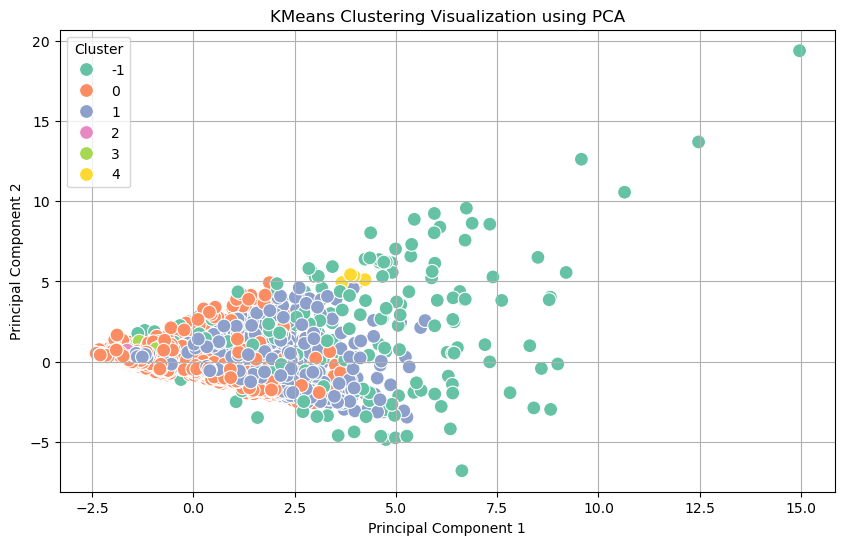

In [83]:
from sklearn.decomposition import PCA

df['Cluster'] = df['DBSCAN_Cluster']

# Reduce dimensions using PCA for visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)

# Add PCA results to DataFrame
df['PCA1'] = pca_components[:, 0]
df['PCA2'] = pca_components[:, 1]

# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='Set2', s=100)
plt.title("KMeans Clustering Visualization using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Cluster')
plt.grid(True)
plt.show()